# 19.1 Serving a TensorFlow Model

In [1]:
import tensorflow as tf

tf.keras.utils.set_random_seed(42)

2023-10-19 06:17:58.379181: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-10-19 06:17:58.631969: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-10-19 06:17:58.633807: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-10-19 06:17:59.639268: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


## 19.1.1 Using TensorFlow Serving

In [2]:
import tensorflow_datasets as tfds

(ds_train, ds_test), ds_info = tfds.load(
    "mnist",
    split=["train", "test"],
    shuffle_files=True,
    as_supervised=True,
    with_info=True,
)
ds_info

2023-10-19 06:18:01.373730: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2023-10-19 06:18:01.374306: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1960] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


tfds.core.DatasetInfo(
    name='mnist',
    full_name='mnist/3.0.1',
    description="""
    The MNIST database of handwritten digits.
    """,
    homepage='http://yann.lecun.com/exdb/mnist/',
    data_dir='/home/yuncong/tensorflow_datasets/mnist/3.0.1',
    file_format=tfrecord,
    download_size=11.06 MiB,
    dataset_size=21.00 MiB,
    features=FeaturesDict({
        'image': Image(shape=(28, 28, 1), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=10),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    splits={
        'test': <SplitInfo num_examples=10000, num_shards=1>,
        'train': <SplitInfo num_examples=60000, num_shards=1>,
    },
    citation="""@article{lecun2010mnist,
      title={MNIST handwritten digit database},
      author={LeCun, Yann and Cortes, Corinna and Burges, CJ},
      journal={ATT Labs [Online]. Available: http://yann.lecun.com/exdb/mnist},
      volume={2},
      year={2010}
    }""",
)

2023-10-19 06:18:01.548064: W tensorflow/core/kernels/data/cache_dataset_ops.cc:854] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


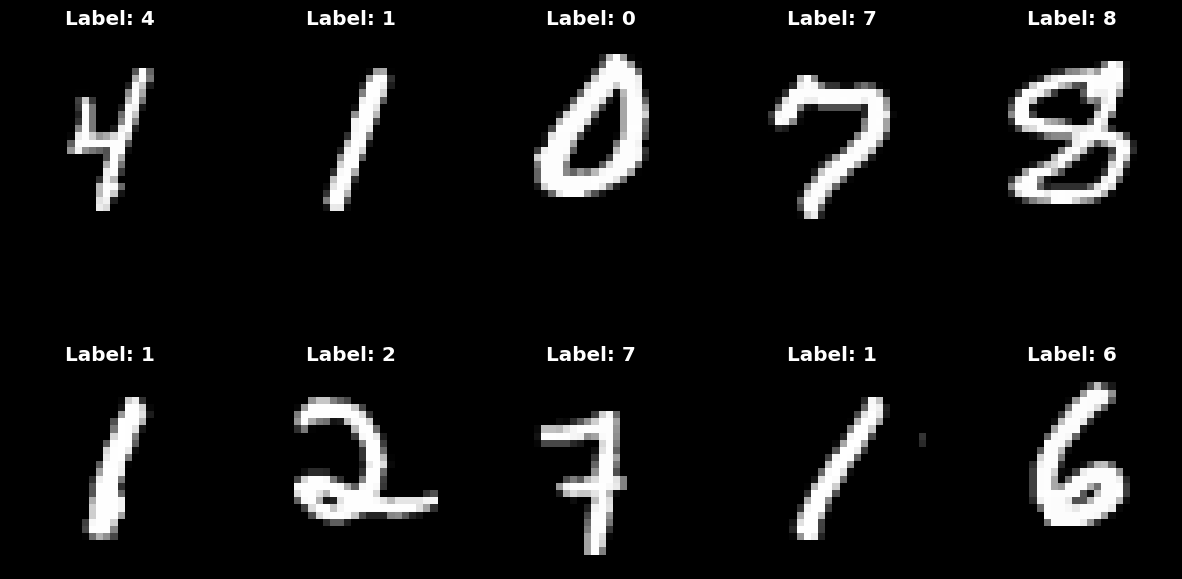

In [3]:
from typing import Optional, Sequence
import matplotlib.pyplot as plt


def plot_images_labels(
    images: Sequence[Sequence[int]],
    labels: Optional[Sequence[int]],
    subtitle_prefix: str = "",
    title: str = "",
):
    n_images = len(images)
    n_cols = 5
    n_rows = round(n_images / n_cols)
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(15, 8))

    for ax, img, label in zip(axs.ravel(), images, labels):
        ax.imshow(img, cmap="gray")
        ax.axis("off")
        ax.set_title(
            f"{subtitle_prefix + ': ' if subtitle_prefix else ''}{label}",
            fontsize="x-large",
            fontweight="bold",
        )

    fig.suptitle(title, fontsize="xx-large", fontweight="bold")


images, labels = zip(*ds_train.take(10))
labels = [label.numpy() for label in labels]
plot_images_labels(images=images, labels=labels, subtitle_prefix="Label")

In [4]:
images[0].shape

TensorShape([28, 28, 1])

In [5]:
def normalize_img(image, label):
    """Normalizes images: `uint8` -> `float32`."""
    return tf.cast(image, tf.float32) / 255.0, label


ds_train = ds_train.map(normalize_img, num_parallel_calls=tf.data.AUTOTUNE)
ds_train = ds_train.cache()
ds_train = ds_train.shuffle(ds_info.splits["train"].num_examples)
ds_train = ds_train.batch(128)
ds_train = ds_train.prefetch(tf.data.AUTOTUNE)
ds_train

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>

In [6]:
ds_test = ds_test.map(normalize_img, num_parallel_calls=tf.data.AUTOTUNE)
ds_test = ds_test.batch(128)
ds_test = ds_test.cache()
ds_test = ds_test.prefetch(tf.data.AUTOTUNE)
ds_test

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>

In [7]:
%load_ext tensorboard
%tensorboard --logdir=./logs --port=6006

In [8]:
# model = tf.keras.models.Sequential([
#   tf.keras.layers.Flatten(input_shape=(28, 28, 1)),
#   tf.keras.layers.Dense(128, activation='relu'),
#   tf.keras.layers.Dense(10)
# ])
model = tf.keras.models.Sequential(
    [
        tf.keras.layers.Conv2D(
            32,
            (3, 3),
            activation="selu",
            kernel_initializer="lecun_normal",
            input_shape=(28, 28, 1),
        ),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(
            64, (3, 3), activation="selu", kernel_initializer="lecun_normal"
        ),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(400, activation="relu"),
        tf.keras.layers.Dense(10),
    ]
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy()],
)
model.summary()
history = model.fit(
    ds_train,
    epochs=20,
    validation_data=ds_test,
    callbacks=[
        tf.keras.callbacks.TensorBoard(log_dir="./logs"),
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    ],
)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d (MaxPooling2  (None, 13, 13, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 11, 11, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 5, 5, 64)          0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 1600)              0         
                                                                 
 dense (Dense)               (None, 400)               6

In [9]:
model.input_names

['conv2d_input']

In [10]:
model.output_names

['dense_1']

In [11]:
model.evaluate(ds_test)

17/79 [=====>........................] - ETA: 0s - loss: 0.0366 - sparse_categorical_accuracy: 0.9903

79/79 [==============================] - 1s 18ms/step - loss: 0.0366 - sparse_categorical_accuracy: 0.9889


[0.03655095398426056, 0.9889000058174133]

1/1 [==============================] - 0s 29ms/step


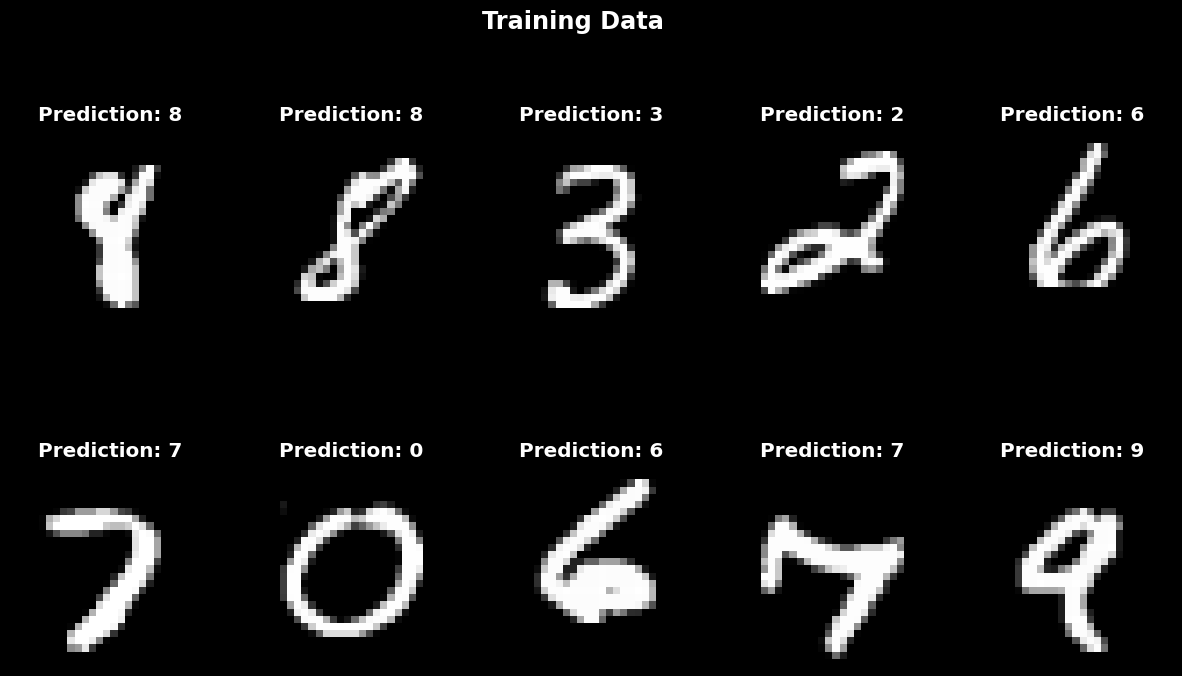

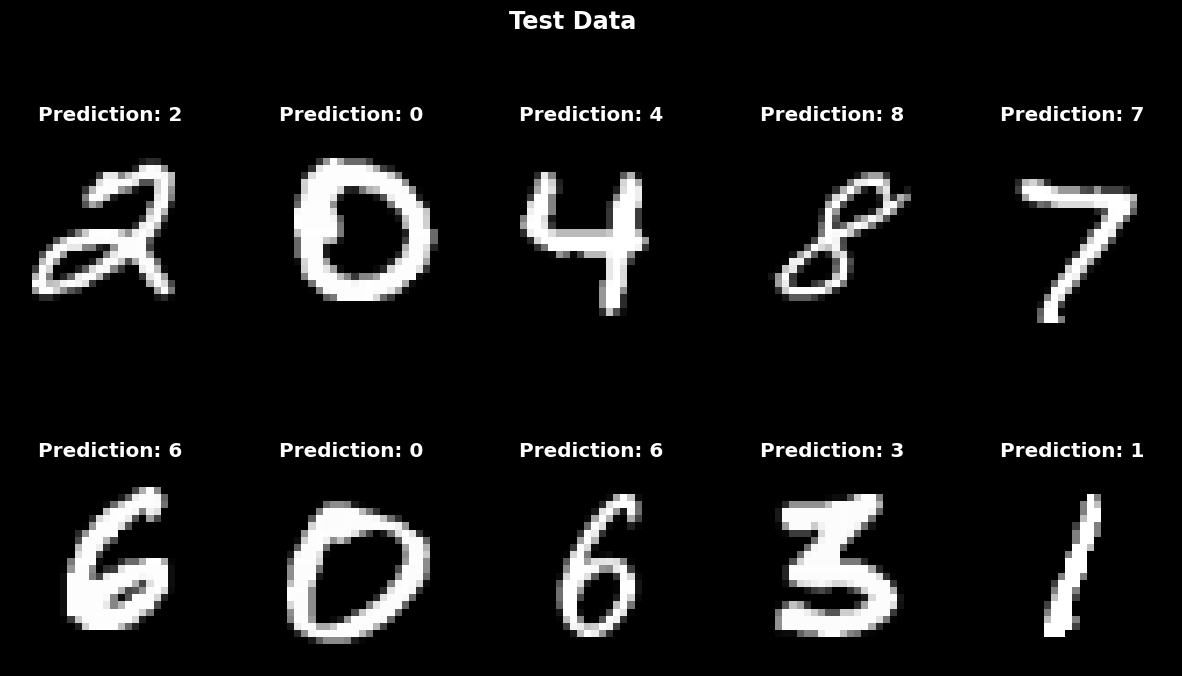

In [12]:
import numpy as np

n_imgs = 10

for batch in ds_train.take(1):
    images = batch[0][:n_imgs]
    predictions = np.argmax(model.predict(images), axis=1)
    plot_images_labels(
        images=images,
        labels=predictions,
        subtitle_prefix="Prediction",
        title="Training Data",
    )

for batch in ds_test.take(1):
    images = batch[0][:n_imgs]
    # labels = batch[1]
    # labels = [label.numpy() for label in labels]
    predictions = np.argmax(model.predict(images), axis=1)
    plot_images_labels(
        images=images,
        labels=predictions,
        subtitle_prefix="Prediction",
        title="Test Data",
    )

##### Exporting SavedModels

In [13]:
import pathlib

model_version = "0002"
model_name = "mnist_model"
model_path = pathlib.Path(model_name, model_version)
tf.saved_model.save(obj=model, export_dir=model_path)

INFO:tensorflow:Assets written to: mnist_model/0002/assets


INFO:tensorflow:Assets written to: mnist_model/0002/assets


In [14]:
import tensorflow as tf

model_saved = tf.saved_model.load("mnist_model/0001")
model_saved

<tensorflow.python.saved_model.load.Loader._recreate_base_user_object.<locals>._UserObject at 0x7fb45c68fa10>

In [15]:
hasattr(model_saved, "predict")

False